Step 1 — Load & Explore

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

!test -f diabetes.csv || wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

--2026-06-01 09:50:34--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0s      

2026-06-01 09:50:34 (125 MB/s) - ‘diabetes.csv’ saved [23873/23873]



step 2- clean

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08 

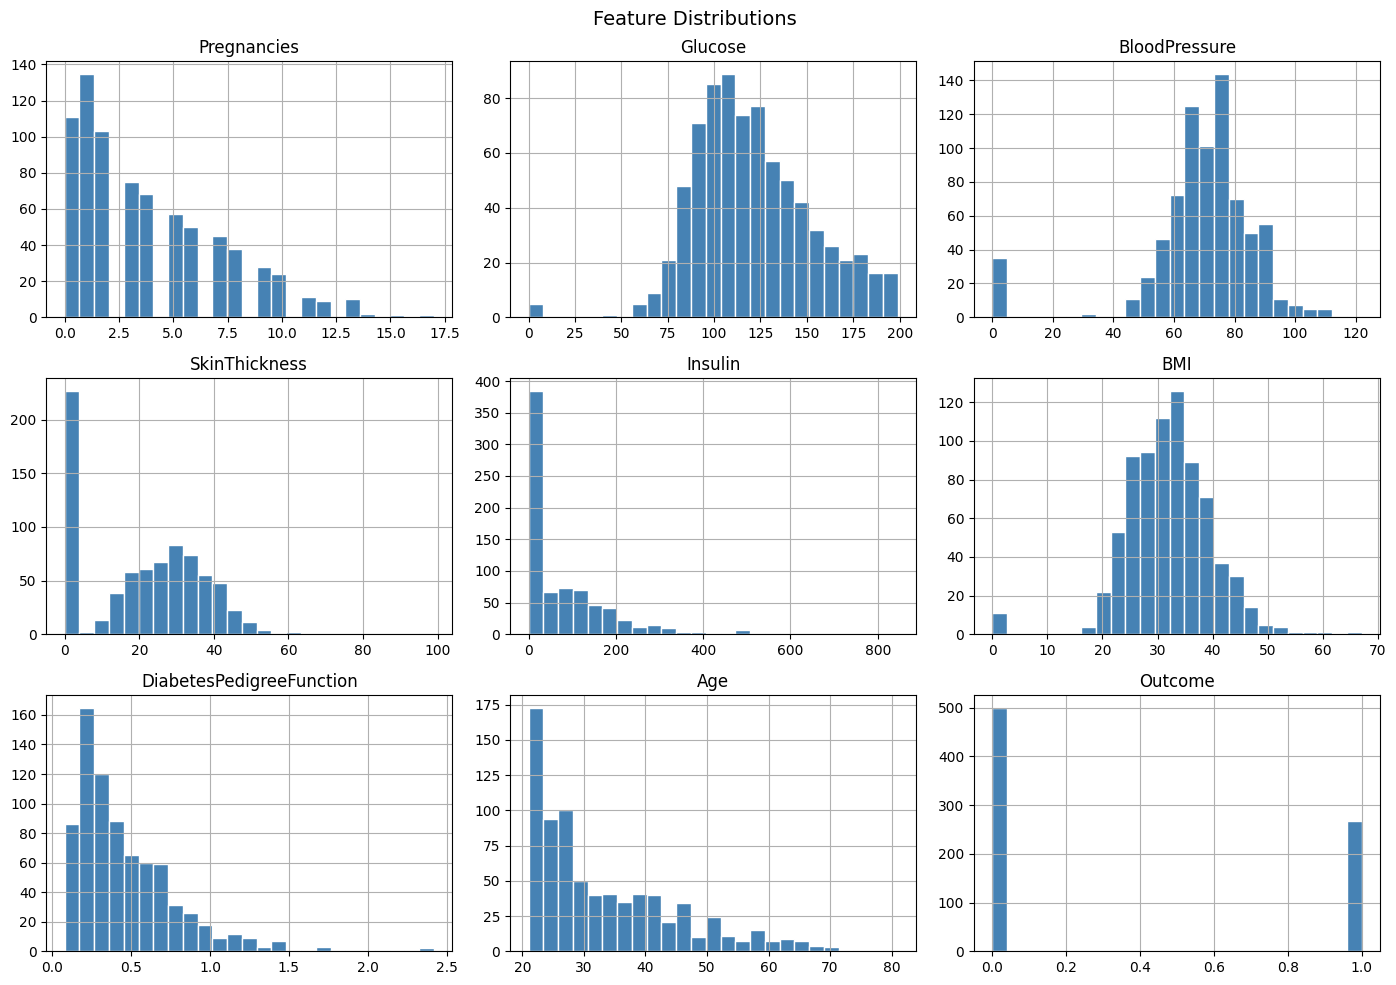

In [3]:
df = pd.read_csv('diabetes.csv') # https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
print(df.shape)
print(df['Outcome'].value_counts())
print(df.describe().round(2))

df.hist(bins=25, figsize=(14,10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14); plt.tight_layout(); plt.show()

step 3-split,scale, train

In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y # stratify keeps class ratio
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit on train, transform train
X_test = scaler.transform(X_test) # only transform test (no leakage!)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# Print learned coefficient for each feature
for name, coef in zip(X.columns, model.coef_[0]):
    print(f'{name:30s}: {coef:+.3f}')

Pregnancies                   : +0.373
Glucose                       : +1.144
BloodPressure                 : -0.198
SkinThickness                 : +0.067
Insulin                       : -0.127
BMI                           : +0.714
DiabetesPedigreeFunction      : +0.256
Age                           : +0.184


Step 4 — Evaluate: Accuracy, Confusion Matrix, ROC

In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Healthy','Diabetic']))


              precision    recall  f1-score   support

     Healthy       0.76      0.82      0.79       100
    Diabetic       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



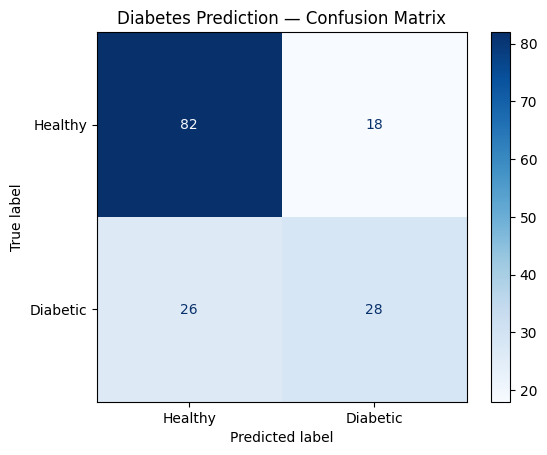

In [11]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(cmap='Blues')
plt.title('Diabetes Prediction — Confusion Matrix'); plt.show()
# ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

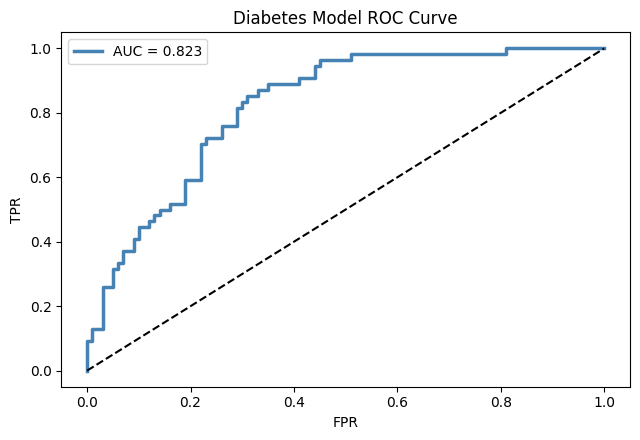

In [12]:
plt.figure(figsize=(6.5, 4.5))
plt.plot(fpr, tpr, lw=2.5, color='steelblue', label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Diabetes Model ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()

Step 5 — Predict for a New Patient

In [18]:
new_patient = np.array([[2, 10, 72, 35, 0, 33.8, 0.61, 80]])
new_scaled = scaler.transform(new_patient) # must use same scaler
pred = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0, 1]
print(f'Prediction : {'Diabetic' if pred==1 else 'Healthy'}')
print(f'Probability : {prob:.1%} chance of having diabetes')

Prediction : Healthy
Probability : 1.8% chance of having diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


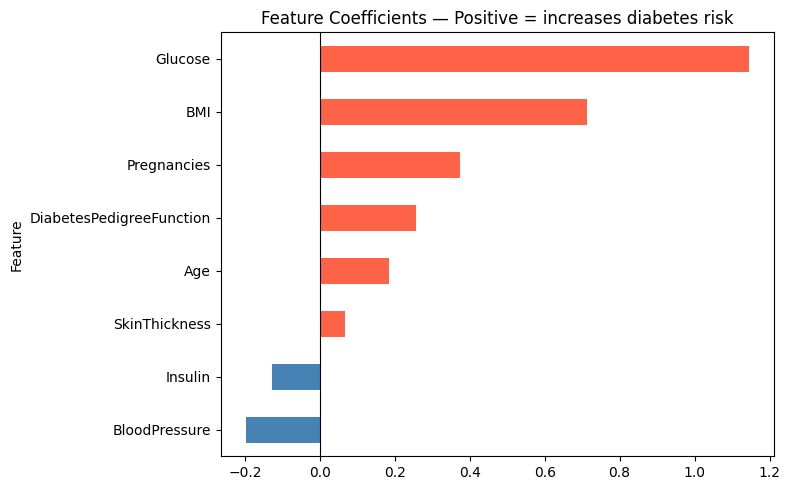

In [20]:
import pandas as pd
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
color=['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']],
legend=False, figsize=(8, 5))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Positive = increases diabetes risk')
plt.tight_layout(); plt.show()